In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


In [2]:
# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith("notebooks"):
    os.chdir("..")
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [3]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DIREKTORI
# ==========================================
TRAIN_DIR = os.path.join("data", "processed", "train")
VAL_DIR = os.path.join("data", "processed", "val")

# Berdasarkan batasan: Resize 300x420 (width, height)
# Dalam Keras, format target_size adalah (height, width)
IMG_HEIGHT = 420
IMG_WIDTH = 300
BATCH_SIZE = 32
NUM_CLASSES = 10


In [4]:
# ==========================================
# 2. PRA-PEMROSESAN & AUGMENTASI DATA (UPDATE)
# ==========================================
print("Menyiapkan Data Generator...")

# Augmentasi diubah agar lebih "aman" untuk citra kartu yang memiliki teks/simbol di sudut
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Dikurangi dari 20 agar sudut kartu tidak terpotong parah
    brightness_range=[0.9, 1.1],# Variasi pencahayaan ringan
    zoom_range=0.05,            # Sangat kecil, sekadar simulasi jarak foto
    horizontal_flip=False,      # PENTING: Dibuat False agar teks & simbol tidak terbalik
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.


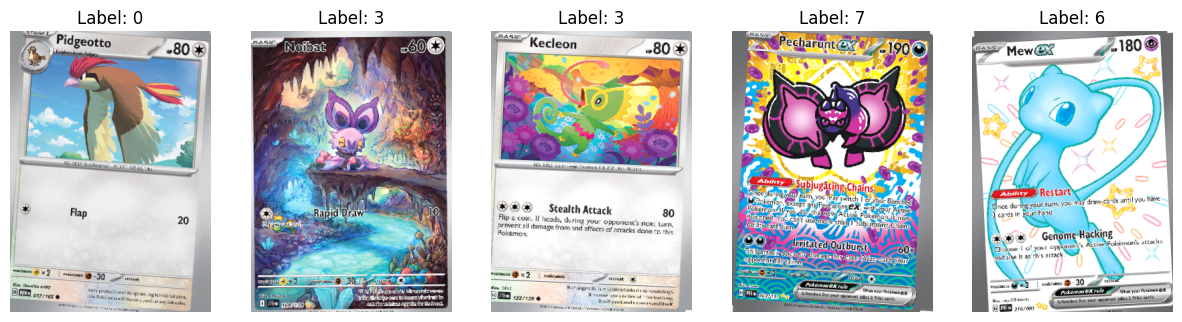

In [5]:
# Mengambil satu batch data latih
x_batch, y_batch = next(train_generator)

# Menampilkan 5 gambar pertama dari batch tersebut
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i].argmax()}")
    plt.axis("off")
plt.show()


In [6]:
# ==========================================
# 3. INISIALISASI MOBILENETV2 & CALLBACKS (UPDATE)
# ==========================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

print("Membangun Arsitektur Model Baru...")

base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
base_model.trainable = False 

# Penambahan layer ekstra untuk mempelajari fitur TCG
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x) # Ditingkatkan untuk mencegah overfitting
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x) # Layer baru + L2 Regularization
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)


Membangun Arsitektur Model Baru...


C:\Users\aryay\AppData\Local\Temp\ipykernel_4684\2967704373.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [7]:
# --- EKSEKUSI TAHAP 1 ---
print("\n=== Memulai Tahap 1: Feature Extraction ===")
history_phase1 = model.fit(
    train_generator,
    epochs=15, # Dinaikkan, tapi akan berhenti otomatis jika sudah optimal
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)



=== Memulai Tahap 1: Feature Extraction ===
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.1713 - loss: 5.3557 - val_accuracy: 0.1765 - val_loss: 4.2365 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.2411 - loss: 3.6863 - val_accuracy: 0.2500 - val_loss: 3.2450 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.2735 - loss: 3.0202 - val_accuracy: 0.2500 - val_loss: 2.9199 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.2947 - loss: 2.6856 - val_accuracy: 0.2824 - val_loss: 2.6751 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.3121 - loss: 2.4821 - val_accuracy: 0.2971 - val_loss: 2.5298 - learning_rate: 0.0010
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.3340 - loss: 2.3643 - val_accuracy: 0.3294 - val_loss: 2.3846 - learning_rate: 0.0010
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/ste

In [8]:
# --- EKSEKUSI TAHAP 2 ---
print("\n=== Memulai Tahap 2: Fine-Tuning ===")
base_model.trainable = True

# Hanya membuka 20 layer terakhir (bukan 100 seperti sebelumnya) agar tidak merusak bobot dasar
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile ulang dengan learning rate sangat kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    epochs=15, # Total epoch maksimal
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr] # Callbacks tetap digunakan
)


=== Memulai Tahap 2: Fine-Tuning ===
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.2642 - loss: 2.3171 - val_accuracy: 0.3353 - val_loss: 2.1310 - learning_rate: 1.0000e-05
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.3427 - loss: 2.1440 - val_accuracy: 0.3059 - val_loss: 2.1103 - learning_rate: 1.0000e-05
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.3720 - loss: 2.0590 - val_accuracy: 0.3147 - val_loss: 2.0919 - learning_rate: 1.0000e-05
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.3988 - loss: 1.9813 - val_accuracy: 0.2912 - val_loss: 2.1040 - learning_rate: 1.0000e-05
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.4087 - loss: 1.9553 - val_accuracy: 0.2971 - val_loss: 2.0887 - learning_rate: 1.0000e-05
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.4330 - loss: 1.8876 - val_accuracy: 0.3118 - val_loss: 2.0786 - learning_rate: 1.0000e-05
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━

In [9]:
# Menyimpan model yang sudah dilatih ke folder models/
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


In [10]:
# ==========================================
# 4. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==========================================
TEST_DIR = os.path.join('data', 'processed', 'test')

# Hanya normalisasi, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: Jangan diacak agar y_true dan y_pred sejajar
)

# Menghitung Akurasi dan Loss dasar
print("Mengevaluasi model...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")

Found 355 images belonging to 10 classes.
Mengevaluasi model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3239 - loss: 2.0063

Akurasi pada Test Set: 32.39%
Loss pada Test Set: 2.0063


Melakukan prediksi pada Test Set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

=== Laporan Klasifikasi (Classification Report) ===
                       precision    recall  f1-score   support

                  151       0.50      0.06      0.11        32
      destined-rivals       0.21      0.74      0.33        38
       evolving-skies       0.50      0.33      0.40        36
     journey-together       0.33      0.03      0.06        29
          lost-origin       0.60      0.66      0.62        38
       paldea-evolved       0.29      0.21      0.24        43
        paldean-fates       0.50      0.47      0.49        38
 prismatic-evolutions       0.36      0.29      0.32        28
scarlet-violet-promos       0.26      0.29      0.27        34
       surging-sparks       0.09      0.05      0.06        39

             accuracy                           0.32       355
            macro avg       0.36      0.31      0.29       355
         weighted avg       0.36      0.32      0.3

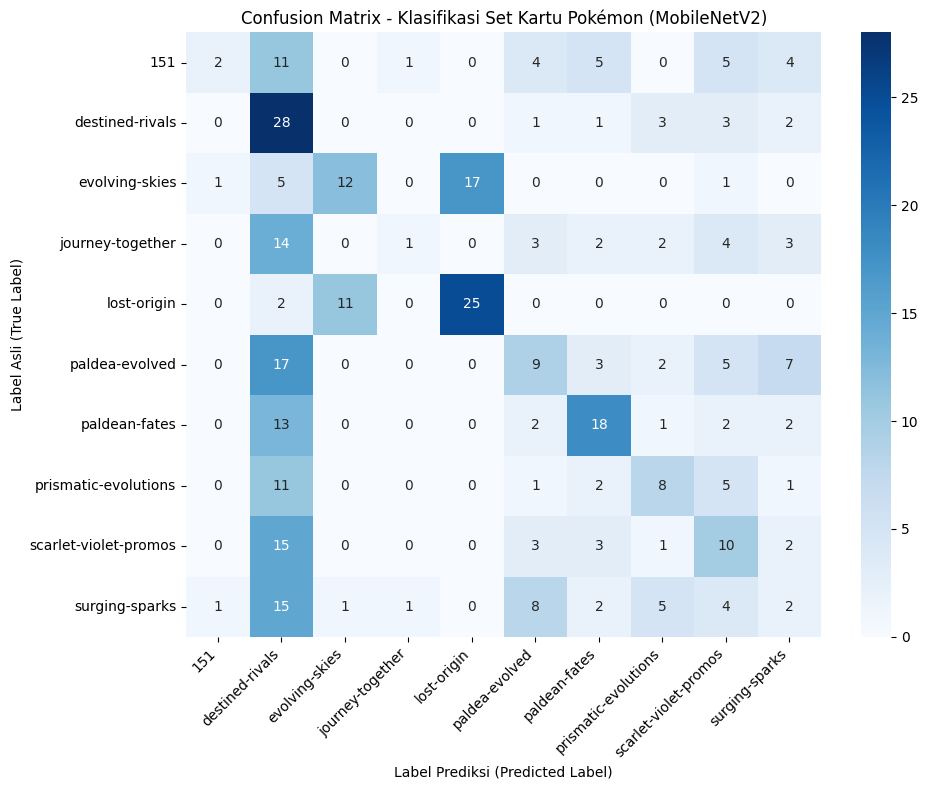

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Melakukan prediksi pada Test Set...")
# Mendapatkan probabilitas prediksi
predictions = model.predict(test_generator)

# Mengambil indeks kelas dengan probabilitas tertinggi (argmax)
y_pred = np.argmax(predictions, axis=1)

# Mengambil label asli dari generator
y_true = test_generator.classes

# Mengambil nama-nama kelas (10 Set Pokémon)
class_names = list(test_generator.class_indices.keys())

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Set Kartu Pokémon (MobileNetV2)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix ke folder reports (opsional tapi disarankan untuk skripsi)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
# Pastikan folder reports ada
os.makedirs('reports', exist_ok=True)
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()

Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


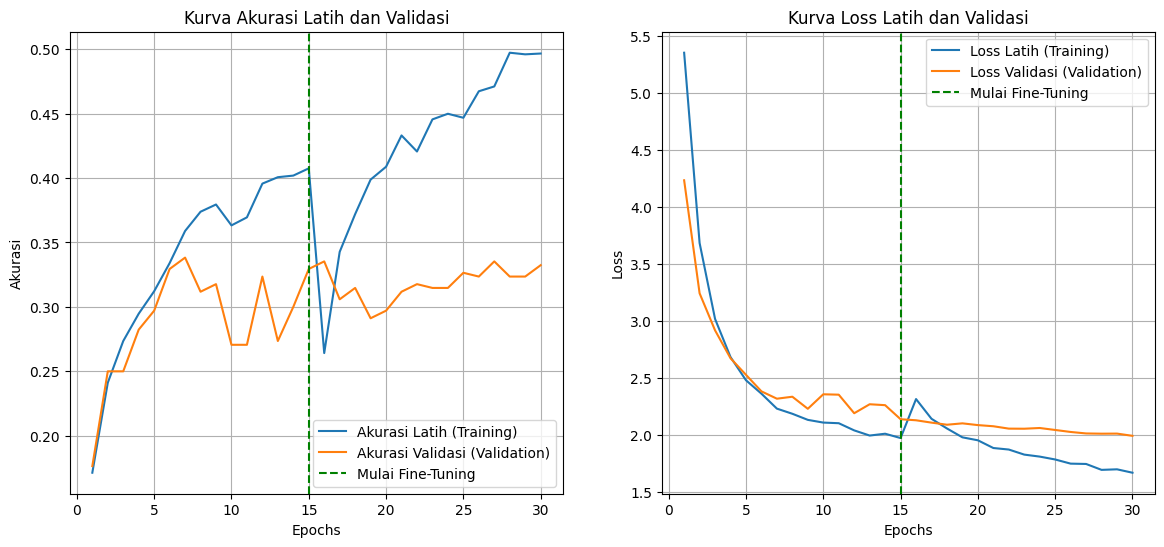

In [12]:
# ==========================================
# 5. VISUALISASI LEARNING CURVES
# ==========================================
print("Menghasilkan Learning Curves...")

# Menggabungkan data metrik dari Tahap 1 (Feature Extraction) dan Tahap 2 (Fine-Tuning)
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Menentukan titik transisi fine-tuning
initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# 1. Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)')
plt.plot(epochs_range, val_loss, label='Loss Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menyimpan grafik ke folder reports
lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()